In [ ]:
from statsmodels.sandbox.distributions.examples.ex_transf2 import test_loggamma

'''
1.data redy -> torchvision.transforms/ torch.utils.data.Dataset/ torch.utils.data.DataLoader
2. build / pick model 
2.1 loss function -> torch.nn/ torch.nn.Module/ torchvision.modules
2.2 optimizer -> torch.optim
3. fit model + predicito
4. evaluate -> torchmetrics
5. improve - expereimentation -> torch.utils.tensorboard
6. save and reload model -> torch.save/ torch.load
'''

In [4]:
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Load an image file into a PyTorch tensor
image = torchvision.io.read_image('corgi.jpg')

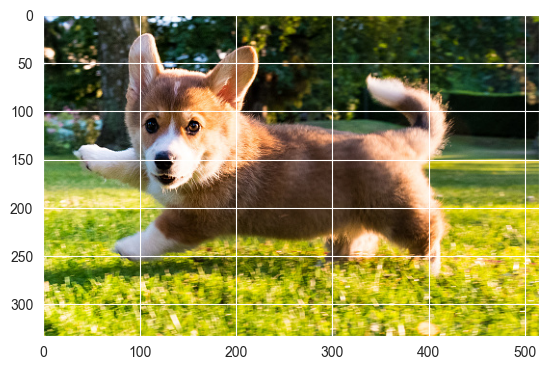

In [3]:
# Create a grid of images
grid = torchvision.utils.make_grid(image)

# Display the grid using matplotlib
plt.imshow(grid.permute(1, 2, 0))
plt.show()

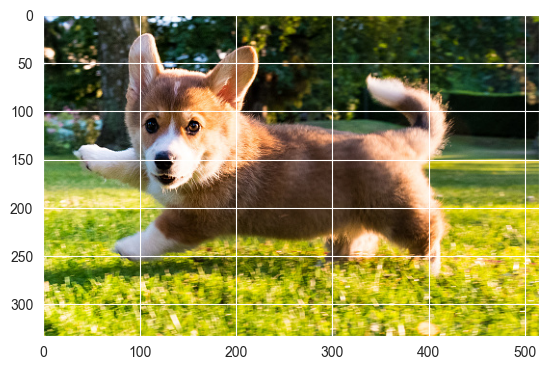

In [5]:
# Load an image file into a Python array
image = Image.open('corgi.jpg')
image_array = np.array(image)

# Display the image using matplotlib
plt.imshow(image_array)
plt.show()

In [ ]:
'''
CNN=
Units are connected with only a few units from the previous layer
Units share weights
'''

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 8)

In [7]:
images = torch.rand(10, 1, 28, 28)
'''10 images with 1 channel, 28x28 hxw'''
# Build 6 conv. filters
conv_filters = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=(3, 3), stride=1, padding=1)
#in channel -> 1 channel
#out_channel -> nb of kernels applied -> nb of features, each learns different things
#kernal_size 
#stride -> how many pixels it moves
#padding -> adds 1 pixel boarder of zeros -> keeps same size
# Convolve the image with the filters
output_feature = conv_filters(images)
print(output_feature.shape)

torch.Size([10, 6, 28, 28])


In [8]:
# Load an image file into a PyTorch tensor
image = torchvision.io.read_image('corgi.jpg').float()

# Normalize the pixel values to be between 0 and 1
image /= 255.0

In [11]:
# Define a convolutional filter with 3 input channels, 10 output channels, and a kernel size of 3
conv_filter = nn.Conv2d(3, 10, kernel_size=3)

In [12]:
print(image.shape)

torch.Size([3, 334, 515])


In [13]:
output = conv_filter(image)

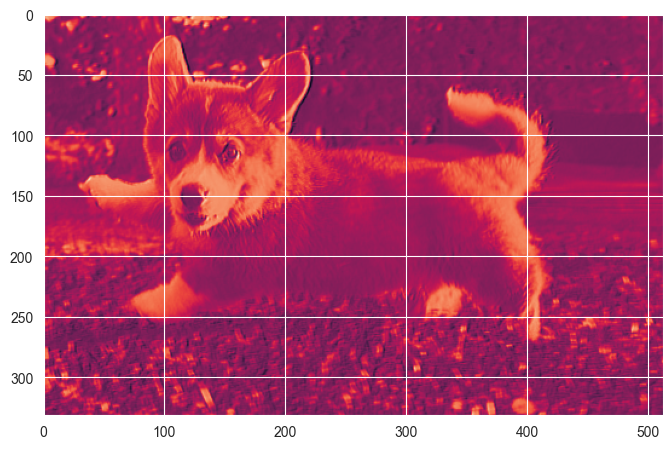

In [14]:
# Create a grid of images
grid = torchvision.utils.make_grid(output)
# Display the grid using matplotlib
plt.imshow(output.detach()[2]) # One 0 is the batch and one is the signal (RGB)
plt.show()

#This is just 1 random filter

EXERCISE 1


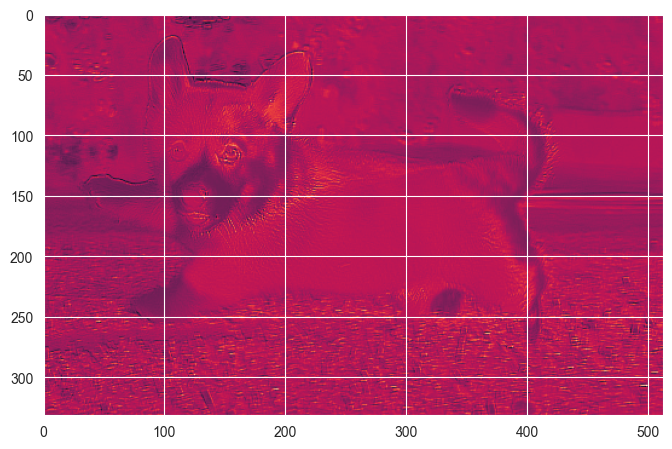

In [20]:
# Ex 1: Look at some other channels
plt.imshow(output.detach()[4])
plt.show()

In [ ]:
'''
torchvision -> datasets , model architectures , image transformations
torchvision.datasets -> baseclasses for custom datasets
torchvision.models -> well-performing  model architectures in pytorch 
torchvision.transforms -> common image transformations
torch.utils.data.Dataset -> base dataset class for pytorch
torch.utils.data.DataLoader -> python iterable over dataser
'''

In [21]:
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

100.0%
100.0%
100.0%
100.0%


In [22]:
# See first training sample
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [23]:
# See classes
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

EXERCISE 2


In [24]:
# Ex 1 Print the len of the train and test datasets
print(len(train_data))
print(len(test_data))

60000
10000


Image shape: torch.Size([1, 28, 28])


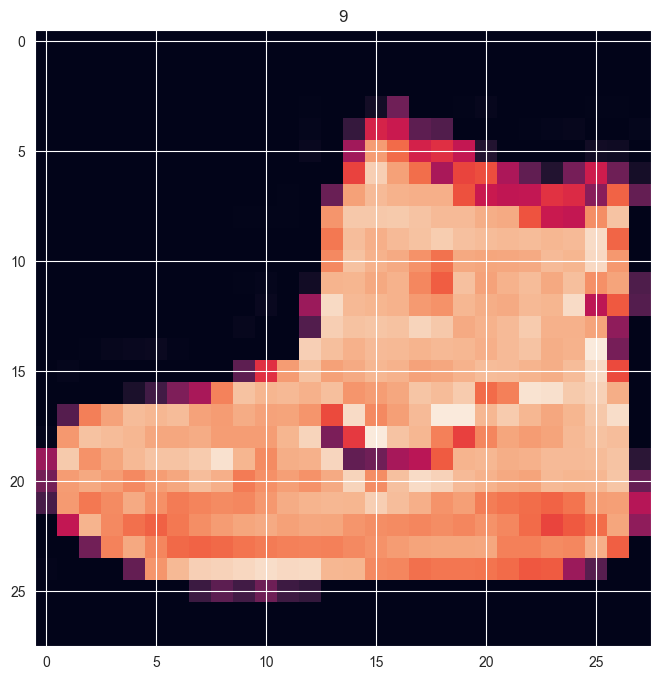

In [25]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(label);

EXERCISE 3


Image shape: torch.Size([1, 28, 28])


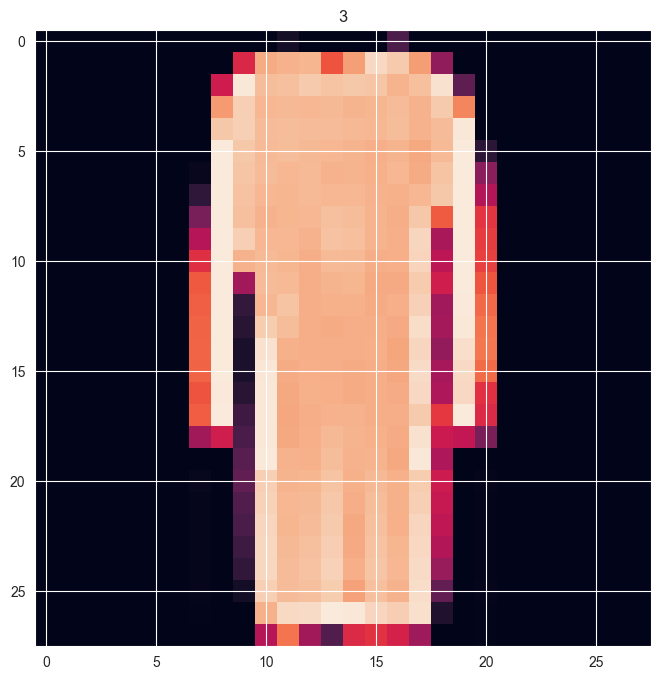

In [26]:
# Now let's look at some random images
# Ex 3 Access some random data from train_data
image, label = train_data[25]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) 
plt.title(label);

Image shape: torch.Size([1, 28, 28])


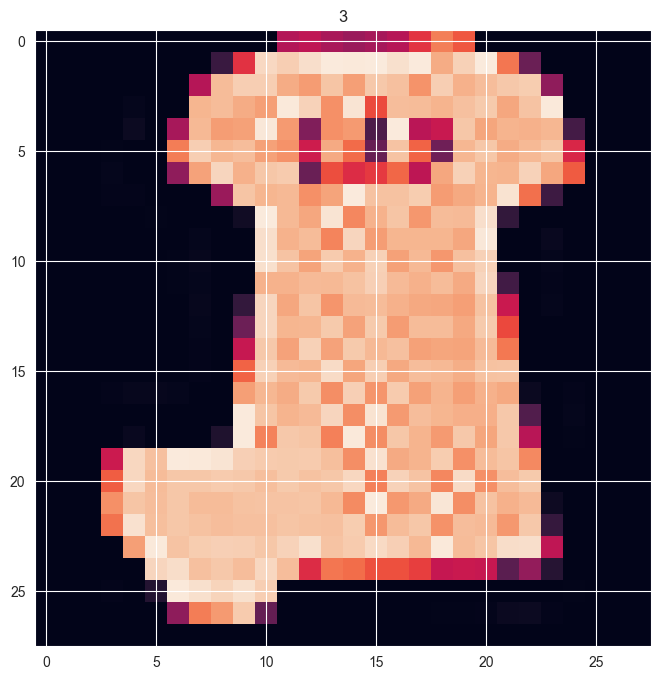

In [27]:
image,label=train_data[70]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(label);

ADDED EXERCISE 3

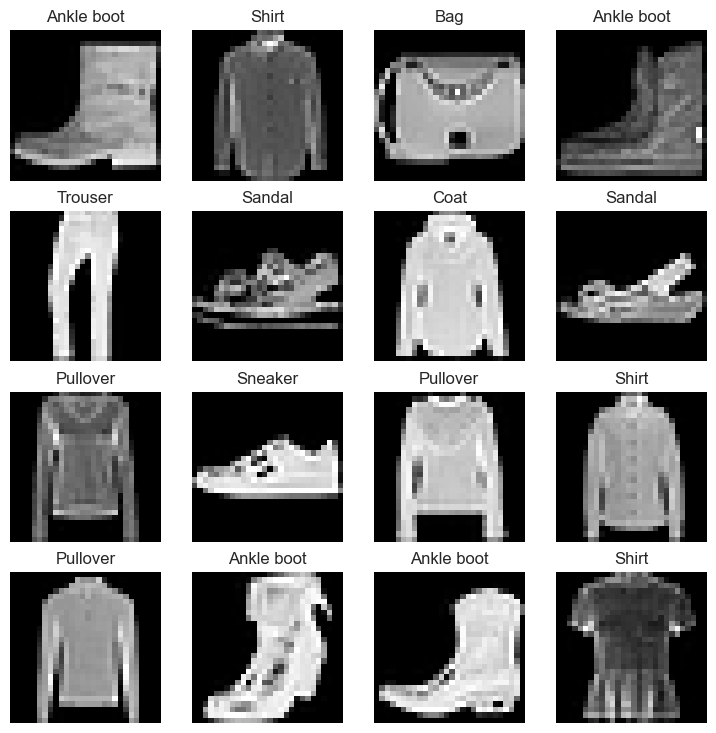

In [31]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    # Ex 3 here
    img,label=train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False);

In [33]:
from torch.utils.data import DataLoader

# Setup the batch size hyperparameter
BATCH_SIZE = 32
#BATCH_SIZE = 64
#BATCH_SIZE = 128
# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch? 
    shuffle=True # shuffle data every epoch?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x00000211B2104350>, <torch.utils.data.dataloader.DataLoader object at 0x00000211B225D4C0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [34]:
# Check out what's inside the training dataloader
# This is how we get some random samples
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

EXERCISE 4

In [ ]:
"""
EXERCISE 4
"""


In [35]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, hidden_units),
            nn.Linear(hidden_units, output_shape)
        )
        
    def forward(self, x):
        return self.layer_stack(x)

In [36]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784, # one for every pixel (28x28)
    hidden_units=10, # how many units in the hiden layer
    output_shape=len(class_names) # one for every class
)


In [37]:
def accuracy_fn(y_true, y_pred):
    """Calculates accuracy between truth labels and predictions.

    Args:
        y_true (torch.Tensor): Truth labels for predictions.
        y_pred (torch.Tensor): Predictions to be compared to predictions.

    Returns:
        [torch.float]: Accuracy value between y_true and y_pred, e.g. 78.45
    """
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

EXERCISE 5


In [38]:
# Ex 5 Define the loss as Cross Entropy loss and the sgd optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_0.parameters(), lr=0.1)

In [40]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    """Prints difference between start and end time.

    Args:
        start (float): Start time of computation (preferred in timeit format). 
        end (float): End time of computation.
        device ([type], optional): Device that compute is running on. Defaults to None.

    Returns:
        float: time between start and end in seconds (higher is longer).
    """
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [ ]:
'''
EXERCISE 6
'''

In [41]:
# Ex 6 Create a loss_values_arr and plot it after the training loop
loss_values_arr = []

In [ ]:
'''
EXERCISE 7
'''

In [43]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epochs (we'll keep this small for faster training times)
epochs = 3

# Create training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-------")
    ### Training
    train_loss = 0
    # Add a loop to loop through training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train() 
        # 1. Forward pass
        y_pred = model_0(X)

        # 2. Calculate loss (per batch)
        loss=loss_fn(y_pred, y)
        train_loss += loss.item()
        
        # 3. Optimizer zero grad
        optimizer.zero_grad()
        
        # 4. Loss backward
        loss.backward()
        
        # 5. Optimizer step
        optimizer.step()
        
        # Print out how many samples have been seen
        if batch % 400 == 0:
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")
    
    train_loss/=len(train_dataloader)
    loss_values_arr.append(train_loss)
    
    ### Testing
    # Setup variables for accumulatively adding up loss and accuracy 
    test_loss, test_acc = 0, 0 
    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            # 1. Forward pass
            test_pred = model_0(X)
           
            # 2. Calculate loss (accumatively)
            test_loss += loss_fn(test_pred, y) # accumulatively add up the loss per epoch

            # 3. Calculate accuracy (preds need to be same as y_true)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
        
        # Calculations on test metrics need to happen inside torch.inference_mode()
        # Divide total test loss by length of test dataloader (per batch)
        test_loss /= len(test_dataloader)

        # Divide total accuracy by length of test dataloader (per batch)
        test_acc /= len(test_dataloader)

    ## Print out what's happening
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")


            
# Calculate training time      
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu, 
                                           end=train_time_end_on_cpu)

C:\Users\Alexandra\PycharmProjects\aiclasses\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 33%|███▎      | 1/3 [00:04<00:09,  4.54s/it]


Train loss: 0.59039 | Test loss: 0.50954, Test acc: 82.04%

Epoch: 1
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


 67%|██████▋   | 2/3 [00:08<00:04,  4.31s/it]


Train loss: 0.47633 | Test loss: 0.47989, Test acc: 83.20%

Epoch: 2
-------
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples


100%|██████████| 3/3 [00:12<00:00,  4.26s/it]


Train loss: 0.45503 | Test loss: 0.47664, Test acc: 83.43%

Train time on None: 12.785 seconds


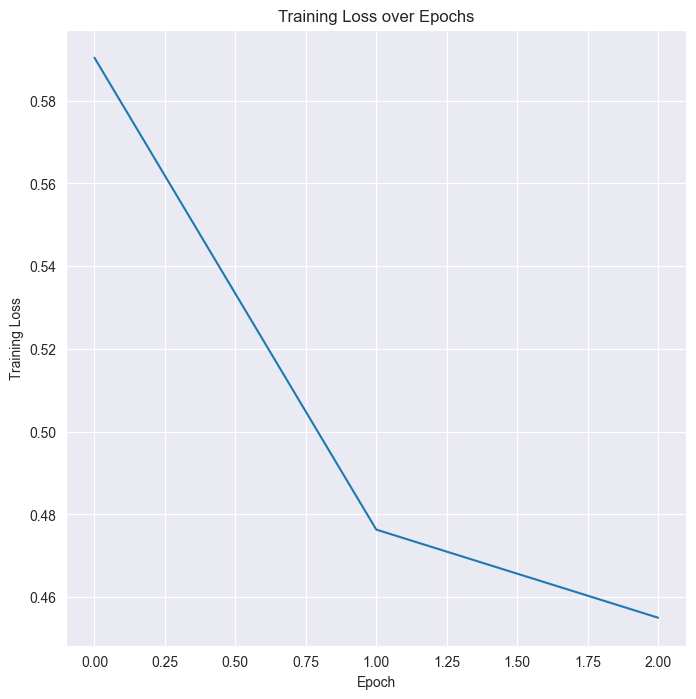

In [44]:
import matplotlib.pyplot as plt

plt.plot(loss_values_arr)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss over Epochs")
plt.show()

In [45]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)
            
            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, 
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
        
        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.47663894295692444,
 'model_acc': 83.42651757188499}

In [46]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [47]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, hidden_units),
            nn.ReLU(),
            nn.Linear(hidden_units, output_shape),
            nn.ReLU()
        )
        
    def forward(self, x):
        return self.layer_stack(x)

In [49]:
torch.manual_seed(42)
model_1 = FashionMNISTModelV0(input_shape=784, # number of input features
    hidden_units=10,
    output_shape=len(class_names) # number of output classes desired
).to(device) # send model to GPU if it's available
next(model_1.parameters()).device # check model device

device(type='cpu')

In [ ]:
'''
# Task 10 Create the same loss + Optimizer as for V0

## Make sure to use after the for loop if you are using a gpu      
# Send data to GPU
# X, y = X.to(device), y.to(device)
'''

In [51]:

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

In [52]:
'''
# Task 11 Train And Test it as before
'''

torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    """Returns a dictionary containing the results of model predicting on data_loader.

    Args:
        model (torch.nn.Module): A PyTorch model capable of making predictions on data_loader.
        data_loader (torch.utils.data.DataLoader): The target dataset to predict on.
        loss_fn (torch.nn.Module): The loss function of model.
        accuracy_fn: An accuracy function to compare the models predictions to the truth labels.

    Returns:
        (dict): Results of model making predictions on data_loader.
    """
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)
            
            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, 
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
        
        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_1_results = eval_model(model=model_1, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_1_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 2.3021068572998047,
 'model_acc': 10.75279552715655}

In [ ]:
'''
structured data -> row column data -> gradient boosed (radnom forests, XGBoost) -> sklearn.ensemble, XGBoost library

unstructured data -> images , audio, language -> CNN, transformers -> torchvision.models, HuggingFace Transformers

'''

In [53]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
'''
in_channels (int) - Number of channels in the input image.
out_channels (int) - Number of channels produced by the convolution.
kernel_size (int or tuple) - Size of the convolving kernel/filter.
stride (int or tuple, optional) - How big of a step the convolving kernel takes at a time. Default: 1.
padding (int, tuple, str) - Padding added to all four sides of input. Default: 0.
'''

In [54]:
torch.manual_seed(42)

# Create sample batch of random numbers with same size as image batch
images = torch.randn(size=(32, 3, 64, 64)) # [batch_size, color_channels, height, width]
test_image = images[0] # get a single image for testing

In [55]:
torch.manual_seed(42)

# Create a convolutional layer with same dimensions as TinyVGG 
# (try changing any of the parameters and see what happens)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0) # also try using "valid" or "same" here 

# Pass the data through the convolutional layer
conv_layer(test_image) # Note: If running PyTorch <1.11.0, this will error because of shape issues (nn.Conv.2d() expects a 4d tensor as input) 

tensor([[[ 1.5396,  0.0516,  0.6454,  ..., -0.3673,  0.8711,  0.4256],
         [ 0.3662,  1.0114, -0.5997,  ...,  0.8983,  0.2809, -0.2741],
         [ 1.2664, -1.4054,  0.3727,  ..., -0.3409,  1.2191, -0.0463],
         ...,
         [-0.1541,  0.5132, -0.3624,  ..., -0.2360, -0.4609, -0.0035],
         [ 0.2981, -0.2432,  1.5012,  ..., -0.6289, -0.7283, -0.5767],
         [-0.0386, -0.0781, -0.0388,  ...,  0.2842,  0.4228, -0.1802]],

        [[-0.2840, -0.0319, -0.4455,  ..., -0.7956,  1.5599, -1.2449],
         [ 0.2753, -0.1262, -0.6541,  ..., -0.2211,  0.1999, -0.8856],
         [-0.5404, -1.5489,  0.0249,  ..., -0.5932, -1.0913, -0.3849],
         ...,
         [ 0.3870, -0.4064, -0.8236,  ...,  0.1734, -0.4330, -0.4951],
         [-0.1984, -0.6386,  1.0263,  ..., -0.9401, -0.0585, -0.7833],
         [-0.6306, -0.2052, -0.3694,  ..., -1.3248,  0.2456, -0.7134]],

        [[ 0.4414,  0.5100,  0.4846,  ..., -0.8484,  0.2638,  1.1258],
         [ 0.8117,  0.3191, -0.0157,  ...,  1

In [ ]:
# Extra Ex : Play with kernal size and stride and see what happens to the shapes

In [57]:
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=5,
                       stride=2,
                       padding=0) 
conv_layer(test_image)

tensor([[[-0.5948, -1.5861,  0.8046,  ..., -0.6760, -0.4141,  0.4623],
         [-0.0281, -1.2165,  0.5269,  ..., -0.8251, -0.2775, -0.2484],
         [-0.1658,  0.4648, -0.3005,  ..., -0.9099, -0.4357,  0.2979],
         ...,
         [ 0.6630,  0.1141,  0.5544,  ..., -1.0168, -0.3645,  0.4765],
         [ 0.3496,  0.8934, -0.5567,  ..., -0.2924,  0.2305,  1.0192],
         [-0.8416,  0.1793, -0.1085,  ...,  0.1477, -1.6401, -0.6631]],

        [[ 0.1400, -1.0109,  0.1728,  ..., -0.6495, -0.2606, -0.7517],
         [ 0.1587,  1.5218,  0.3420,  ...,  0.5767,  0.7092,  0.1965],
         [ 0.0420,  0.2219, -0.5887,  ..., -1.6640, -0.6538, -0.6595],
         ...,
         [-0.6441, -0.2478,  0.4476,  ..., -0.6757,  0.0094, -0.1254],
         [ 0.5479,  0.7785,  1.0805,  ..., -0.3178,  0.4692, -0.1884],
         [-0.6935,  0.0421, -0.4753,  ...,  0.2703, -0.1246,  0.7032]],

        [[ 1.7556, -0.7634,  0.1600,  ...,  0.1093, -0.2073, -0.3486],
         [ 0.2397, -0.0703, -0.0018,  ...,  0

In [65]:
# Create a convolutional neural network 
class FashionMNISTModelV2(nn.Module):
    """
    Model architecture copying TinyVGG from: 
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units, 
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1),# options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number 
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #this flattens the (hidden,7,7)-> hidden*7*7
            # Where did this in_features shape come from? 
            # It's because each layer of our network compresses and changes the shape of our inputs data.
            nn.Linear(in_features=hidden_units*7*7, 
                      out_features=output_shape)
        )
    
    def forward(self, x: torch.Tensor):
        x = self.block_1(x)
        #print(x.shape)
        x = self.block_2(x)
        #print(x.shape)
        x = self.classifier(x)
        #print(x.shape)
        return x

torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1, 
    hidden_units=10, 
    output_shape=len(class_names)).to(device)
model_2

FashionMNISTModelV2(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [59]:
import torch
import torch.nn as nn

# Create a random 2D tensor of shape (1, 1, 4, 4)
input_tensor = torch.rand(1, 1, 4, 4)

# Define a max pooling layer with a kernel size of (2, 2)
maxpool_layer = nn.MaxPool2d(kernel_size=(2, 2))

# Apply the max pooling layer to the input tensor
output_tensor = maxpool_layer(input_tensor)

# Print the input and output tensor shapes
print("Input shape:", input_tensor.shape)
print("Output shape:", output_tensor.shape)

Input shape: torch.Size([1, 1, 4, 4])
Output shape: torch.Size([1, 1, 2, 2])


In [ ]:
'''
# EX 12 Train and evaluate this model 
# When training convert output from logits like
    # # Do the forward pass
    # y_logit = model_2(X)
    # # Turn predictions from logits -> prediction probabilities -> predictions labels
    # y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
    
# Also compare the results(accuracy) and the training time
'''

In [66]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, 
                                y_pred=y_pred.argmax(dim=1)) 
        
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, 
            "model_loss": loss.item(),
            "model_acc": acc}


In [70]:
torch.manual_seed(42)
train_time_start_on_cpu = timer()
optimizer = torch.optim.SGD(model_2.parameters(), lr=0.1)
loss_fn = torch.nn.CrossEntropyLoss()
loss_values_arr = []
epochs=3
for epoch in range(epochs):
    print(f"EPoch: {epoch}\n-----------")
    
    model_2.train()
    train_loss=0
    
    for batch,(x,y) in enumerate(train_dataloader):
        y_logit=model_2(x)
        loss=loss_fn(y_logit, y)
        train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 400 == 0:
            print(f"Seen {batch*len(x)}/{len(train_dataloader.dataset)} sampels")
    train_loss/=len(train_dataloader)
    loss_values_arr.append(train_loss)
    
    test_loss,test_acc=0,0
    model_2.eval()
    
    with torch.inference_mode():
        for x,y in test_dataloader:
            test_logit=model_2(x)
            test_loss += loss_fn(test_logit, y).item()
            y_pred=torch.softmax(test_logit, dim=1).argmax(dim=1)
            test_acc += accuracy_fn(y_true=y, y_pred=y_pred)
        test_loss/=len(test_dataloader)
        test_acc/=len(test_dataloader)
    
    train_time_end_on_cpu = timer()
    print(f"\n Train loss: {train_loss:.4f} Test loss: {test_loss:.4f} Test acc: {test_acc:.4f}")

EPoch: 0
-----------
Seen 0/60000 sampels
Seen 12800/60000 sampels
Seen 25600/60000 sampels
Seen 38400/60000 sampels
Seen 51200/60000 sampels

 Train loss: 0.3044 Test loss: 0.3170 Test acc: 88.6482
EPoch: 1
-----------
Seen 0/60000 sampels
Seen 12800/60000 sampels
Seen 25600/60000 sampels
Seen 38400/60000 sampels
Seen 51200/60000 sampels

 Train loss: 0.2895 Test loss: 0.3052 Test acc: 88.9377
EPoch: 2
-----------
Seen 0/60000 sampels
Seen 12800/60000 sampels
Seen 25600/60000 sampels
Seen 38400/60000 sampels
Seen 51200/60000 sampels

 Train loss: 0.2793 Test loss: 0.3065 Test acc: 88.7380


In [71]:
model_2_train_time = print_train_time(
    start=train_time_start_on_cpu,
    end=train_time_end_on_cpu,
    device=str(next(model_2.parameters()).device)
)

Train time on cpu: 40.775 seconds


In [72]:
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

print("Model 0:", model_0_results)
print("Model 2:", model_2_results)

print("Training time:", model_2_train_time)

Model 0: {'model_name': 'FashionMNISTModelV0', 'model_loss': 0.47663894295692444, 'model_acc': 83.42651757188499}
Model 2: {'model_name': 'FashionMNISTModelV2', 'model_loss': 0.30650395154953003, 'model_acc': 88.73801916932908}
Training time: 40.774709000004805
